# Aspect Ratio Scaling

This notebook examines how focusing efficiency varies with the aspect ratio (thickness / minimum feature size) of diffractive elements across a range of X-ray energies. It compares optimized cascades to Fresnel zone plates and identifies the minimum aspect ratio needed to achieve a target efficiency at each energy, demonstrating that cascades relax the extreme aspect ratio requirements of conventional single-element optics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))

In [3]:
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams.update({'font.size': 24})

In [4]:
path = repo_root / "paper_data"
results = np.load(path / "fig2a_thickness_energy_sweep_results.npz", allow_pickle=True)
params = np.load(path / "fig2a_thickness_energy_sweep_params.npy", allow_pickle=True).item()
sweep_arrs = np.load(path / "fig2a_thickness_energy_sweep_sweep_arrays.npy", allow_pickle=True).item()

opt_objs = results["opt_objs"].T
fzp_objs = results["fzp_objs"].T

opt_efficiencies = opt_objs / params['Nx']
fzp_efficiencies = fzp_objs / params['Nx']

thicknesses = sweep_arrs["thicknesses"]
energies = sweep_arrs["energies"]
aspect_ratios = thicknesses / params["min_feature_size"]

energy_stride = 3
energy_idx = np.arange(0, len(energies), energy_stride)
energies = energies[energy_idx]
opt_efficiencies = opt_efficiencies[energy_idx]
fzp_efficiencies = fzp_efficiencies[energy_idx]

In [5]:
efficiency_threshold = 0.1

fzp_min_ars = np.zeros(energies.shape)
opt_min_ars = np.zeros(energies.shape)

for i in range(len(energies)):
    for j, ar in enumerate(aspect_ratios):
        if fzp_efficiencies[i, j] > efficiency_threshold:
            fzp_min_ars[i] = ar
            break

    for j, ar in enumerate(aspect_ratios):
        if opt_efficiencies[i, j] > efficiency_threshold:
            opt_min_ars[i] = ar
            break

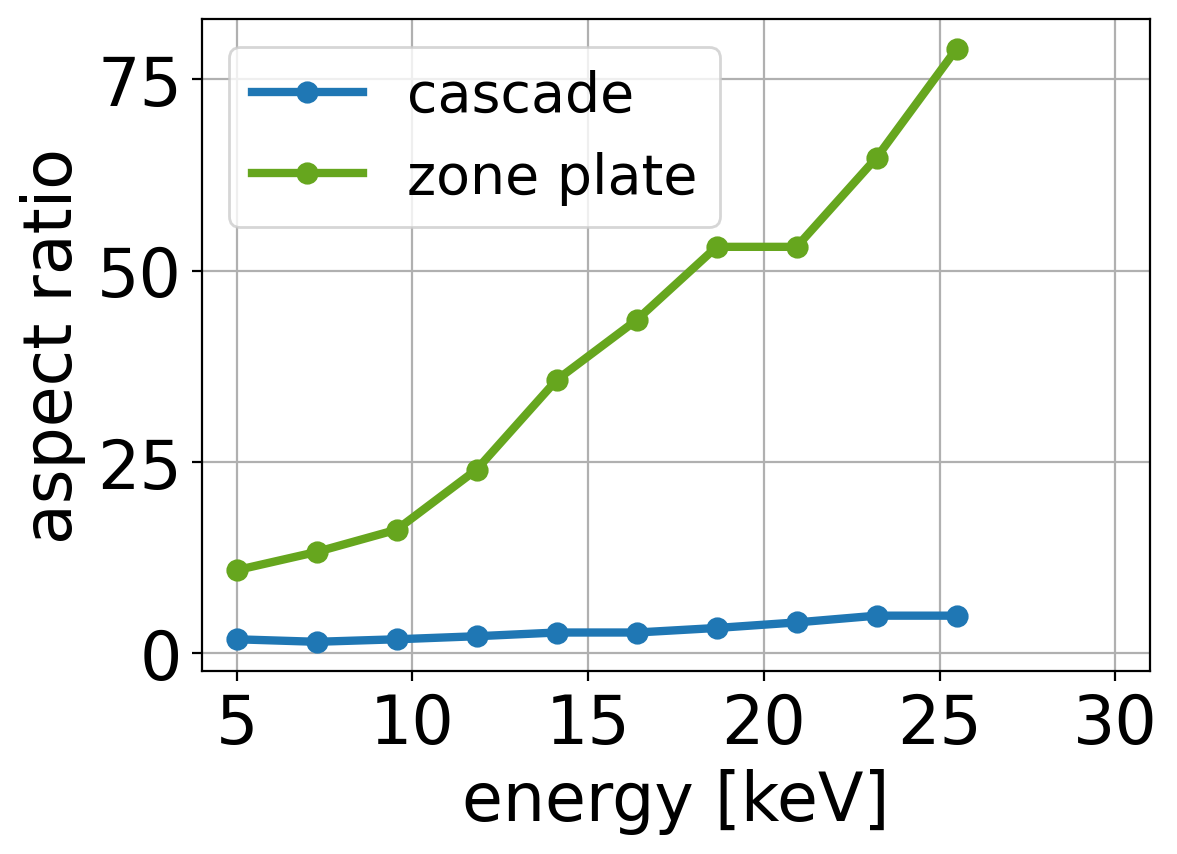

In [6]:
fzp_color = (
    np.float64(0.4),
    np.float64(0.6509803921568628),
    np.float64(0.11764705882352941),
    np.float64(1.0),
)

plt.plot(energies / 1e3, opt_min_ars, linewidth=3, marker="o", markersize=7, label="cascade")
plt.plot(energies / 1e3, fzp_min_ars, linewidth=3, marker="o", markersize=7, label="zone plate", color=fzp_color)

plt.xlabel("energy [keV]")
plt.ylabel("aspect ratio")
plt.xticks([5, 10, 15, 20, 25, 30])
plt.xlim(4, 31)
plt.legend(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()